# La neurona artificial

En el cuaderno anterior utilizamos una red neuronal pequeña como una caja negra. Ahora vamos a abrir esa caja y concentrarnos en su unidad conceptual más sencilla: una neurona artificial.

Implementaremos con NumPy el recorrido desde las entradas hasta la salida. Observaremos qué aportan los pesos y el bias, aplicaremos una activación sigmoide y representaremos la frontera lineal que puede construir una sola neurona. Los parámetros serán elegidos manualmente: todavía no estudiaremos cómo se entrenan.


## Objetivos del cuaderno

Al finalizar este recorrido, deberías poder:

- calcular la suma ponderada de una neurona a partir de entradas, pesos y bias;
- reproducir ese cálculo mediante operaciones de NumPy;
- aplicar una función sigmoide para transformar el resultado;
- interpretar cómo influyen los pesos y el bias;
- reconocer la limitación lineal de una sola neurona.


## Importación de librerías

Usaremos NumPy para realizar las operaciones numéricas, Pandas para presentar algunos resultados en tablas y Matplotlib para visualizar la activación y las fronteras de decisión.

No necesitamos una biblioteca de Deep Learning en este capítulo: el objetivo es ver de manera explícita el cálculo que esas herramientas realizarán más adelante.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


## 1. Entradas, pesos y bias

Comenzaremos con el ejemplo numérico del notebook. La neurona recibe dos entradas, $x_1=3$ y $x_2=5$, y utiliza un peso para cada una. Después de sumar los productos, agrega un bias:

$$
z = w_1x_1 + w_2x_2 + b
$$

La siguiente tabla nos permitirá ver por separado cuánto aporta cada entrada al resultado.


In [2]:
entradas = np.array([3.0, 5.0])
pesos = np.array([0.4, -0.2])
bias = 0.5

detalle_calculo = pd.DataFrame(
    {
        "Entrada": ["x1", "x2"],
        "Valor": entradas,
        "Peso": pesos,
        "Producto": entradas * pesos,
    }
)

suma_productos = detalle_calculo["Producto"].sum()
z = suma_productos + bias

display(detalle_calculo)
print(f"Suma de los productos: {suma_productos:.1f}")
print(f"Bias: {bias:.1f}")
print(f"Resultado z: {z:.1f}")


,Entrada,Valor,Peso,Producto
0,x1,3.0,0.4,1.2
1,x2,5.0,-0.2,-1.0


Suma de los productos: 0.2
Bias: 0.5
Resultado z: 0.7


La primera entrada aporta **1,2** al cálculo, mientras que la segunda aporta **−1,0** porque su peso es negativo. La suma de ambos aportes es 0,2 y el bias agrega 0,5, por lo que obtenemos $z=0,7$.

El peso no indica por sí solo cuánto aporta una variable: el aporte concreto surge del producto entre la entrada y su peso. El bias, en cambio, se incorpora como un desplazamiento adicional.


## 2. El mismo cálculo con NumPy

Escribir cada multiplicación por separado sería incómodo cuando una neurona recibe muchas entradas. `np.dot()` multiplica cada valor por su peso correspondiente y suma los productos.

Probemos la misma estructura con cinco entradas. También calcularemos el resultado de forma explícita para comprobar que ambas expresiones son equivalentes.


In [3]:
entradas_muchas = np.array([2.5, 1.3, 0.8, 4.1, 3.0])
pesos_muchos = np.array([0.4, -0.1, 0.7, 0.2, -0.3])
bias_muchos = 0.5

z_explicito = np.sum(entradas_muchas * pesos_muchos) + bias_muchos
z_con_dot = np.dot(entradas_muchas, pesos_muchos) + bias_muchos

print(f"Cálculo explícito: {z_explicito:.2f}")
print(f"Cálculo con np.dot(): {z_con_dot:.2f}")


Cálculo explícito: 1.85
Cálculo con np.dot(): 1.85


Ambas formas producen **1,85**. `np.dot()` no cambia la operación matemática; solamente la expresa de una manera más compacta y conveniente.

Una neurona puede recibir muchas entradas, pero debe existir un peso por cada una. Este tipo de operación vectorizada será importante cuando trabajemos con una gran cantidad de cálculos, aunque aquí todavía estamos observando una sola neurona.


Una misma neurona también puede procesar varios casos. Imaginemos un ejemplo simplificado en el que las entradas representan la frecuencia de uso de un servicio y la cantidad de reclamos de cuatro clientes.

Usaremos parámetros elegidos manualmente. El peso negativo de la frecuencia de uso reduce $z$, mientras que el peso positivo de los reclamos lo aumenta. El ejemplo sirve para observar el cálculo, no para tomar decisiones reales sobre clientes.


In [4]:
casos = pd.DataFrame(
    {
        "cliente": ["A", "B", "C", "D"],
        "frecuencia_uso": [5.0, 2.0, 1.0, 4.0],
        "reclamos": [0.0, 1.0, 3.0, 2.0],
    }
)

pesos_clientes = np.array([-0.8, 1.1])
bias_clientes = 0.2

matriz_entradas = casos[["frecuencia_uso", "reclamos"]].to_numpy()
casos["z"] = np.dot(matriz_entradas, pesos_clientes) + bias_clientes

casos


,cliente,frecuencia_uso,reclamos,z
0,A,5.0,0.0,-3.8
1,B,2.0,1.0,-0.3
2,C,1.0,3.0,2.7
3,D,4.0,2.0,-0.8


El cliente A obtiene un valor $z$ muy negativo porque presenta una frecuencia de uso alta y ningún reclamo. El cliente C obtiene un valor positivo porque la baja frecuencia de uso y los tres reclamos empujan el cálculo en la dirección contraria.

Por ahora, $z$ es solamente una combinación numérica de las entradas. Para convertirla en una salida comprendida entre 0 y 1 aplicaremos una función de activación.


## 3. Transformar el resultado con una activación

El capítulo relaciona una neurona con la regresión logística que ya conocemos. Si aplicamos una función sigmoide, los valores negativos y positivos de $z$ se transforman en valores entre 0 y 1:

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

No compararemos todavía distintas funciones de activación. En este punto solo necesitamos observar qué hace una de ellas.


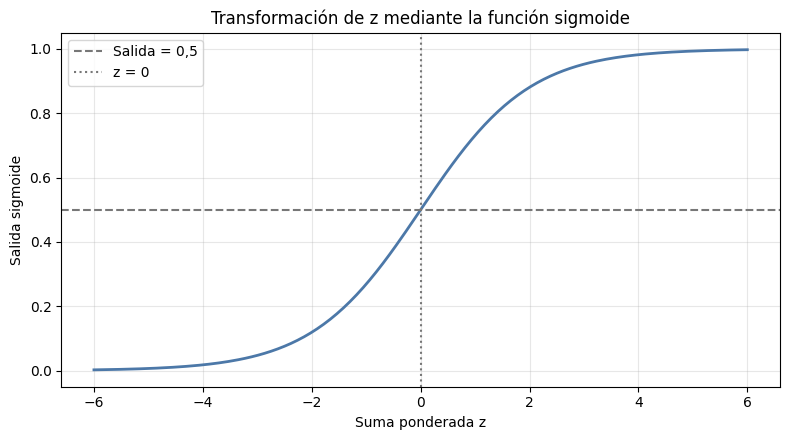

In [5]:
def sigmoide(z):
    return 1 / (1 + np.exp(-z))


valores_z = np.linspace(-6, 6, 200)
salidas_sigmoide = sigmoide(valores_z)

plt.figure(figsize=(8, 4.5))
plt.plot(valores_z, salidas_sigmoide, color="#4C78A8", linewidth=2)
plt.axhline(0.5, color="#777777", linestyle="--", label="Salida = 0,5")
plt.axvline(0, color="#777777", linestyle=":", label="z = 0")
plt.title("Transformación de z mediante la función sigmoide")
plt.xlabel("Suma ponderada z")
plt.ylabel("Salida sigmoide")
plt.ylim(-0.05, 1.05)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


La sigmoide transforma valores muy negativos en salidas cercanas a 0 y valores muy positivos en salidas cercanas a 1. Cuando $z=0$, la salida es exactamente 0,5.

La transformación es continua: no convierte automáticamente el resultado en una categoría. En una clasificación binaria podemos usar un umbral, por ejemplo 0,5, para obtener una decisión de clase.


Apliquemos ahora la sigmoide a los cuatro valores calculados. Llamaremos “clase 1” a las salidas iguales o superiores a 0,5 y “clase 0” a las restantes.

En este ejemplo, el número entre 0 y 1 funciona como una salida similar a la de una regresión logística. No debe interpretarse como una probabilidad confiable en una aplicación real, porque los parámetros no fueron aprendidos ni validados con datos.


In [6]:
casos["salida_sigmoide"] = sigmoide(casos["z"])
casos["clase_predicha"] = (casos["salida_sigmoide"] >= 0.5).astype(int)

casos.assign(
    z=casos["z"].round(2),
    salida_sigmoide=casos["salida_sigmoide"].round(3),
)


,cliente,frecuencia_uso,reclamos,z,salida_sigmoide,clase_predicha
0,A,5.0,0.0,-3.8,0.022,0
1,B,2.0,1.0,-0.3,0.426,0
2,C,1.0,3.0,2.7,0.937,1
3,D,4.0,2.0,-0.8,0.310,0


Los valores positivos de $z$ quedan por encima de 0,5 y se asignan a la clase 1; los negativos quedan por debajo y se asignan a la clase 0. El umbral de la sigmoide coincide con $z=0$.

La tabla muestra una **predicción con parámetros actuales**, pero no un aprendizaje. Los pesos `[-0.8, 1.1]` y el bias `0.2` siguen siendo decisiones manuales del ejemplo.


## 4. Cómo cambian la salida los parámetros

Mantendremos fijas las entradas del cliente B y cambiaremos un elemento por vez. Así podremos distinguir el efecto de los pesos y el bias sin introducir todavía un proceso de entrenamiento.


In [7]:
entrada_b = np.array([2.0, 1.0])

escenarios = [
    ("Parámetros iniciales", np.array([-0.8, 1.1]), 0.2),
    ("Mayor peso para reclamos", np.array([-0.8, 1.8]), 0.2),
    ("Uso con peso cero", np.array([0.0, 1.1]), 0.2),
    ("Bias más alto", np.array([-0.8, 1.1]), 1.2),
]

resultados_escenarios = []

for nombre, pesos_escenario, bias_escenario in escenarios:
    z_escenario = np.dot(entrada_b, pesos_escenario) + bias_escenario
    resultados_escenarios.append(
        {
            "Escenario": nombre,
            "Peso uso": pesos_escenario[0],
            "Peso reclamos": pesos_escenario[1],
            "Bias": bias_escenario,
            "z": z_escenario,
            "Salida": sigmoide(z_escenario),
        }
    )

pd.DataFrame(resultados_escenarios).round(3)


,Escenario,Peso uso,Peso reclamos,Bias,z,Salida
0,Parámetros iniciales,-0.8,1.1,0.2,-0.3,0.426
1,Mayor peso para reclamos,-0.8,1.8,0.2,0.4,0.599
2,Uso con peso cero,0.0,1.1,0.2,1.3,0.786
3,Bias más alto,-0.8,1.1,1.2,0.7,0.668


Al aumentar el peso de los reclamos, esa entrada aporta más al resultado. Al llevar a cero el peso de la frecuencia de uso, esa variable deja de influir en el cálculo. Al elevar solamente el bias, toda la combinación se desplaza sin modificar los aportes individuales de las entradas.

Estos cambios no representan mejoras del modelo. Solo muestran que diferentes valores de los parámetros producen diferentes salidas. Aprender consiste en encontrar parámetros adecuados a partir de datos, una cuestión que abordaremos más adelante.


## 5. Una neurona como separador lineal

Con dos entradas podemos representar cada caso como un punto en un plano. La neurona calcula:

$$
z = w_1x_1 + w_2x_2 + b
$$

Si usamos la sigmoide y un umbral de 0,5, la frontera entre las clases aparece donde $z=0$. Esa ecuación describe una recta.

Construiremos un conjunto pequeño de puntos que sí puede separarse mediante una frontera lineal. Los parámetros también serán manuales: buscamos visualizar la capacidad de una neurona, no simular un entrenamiento.


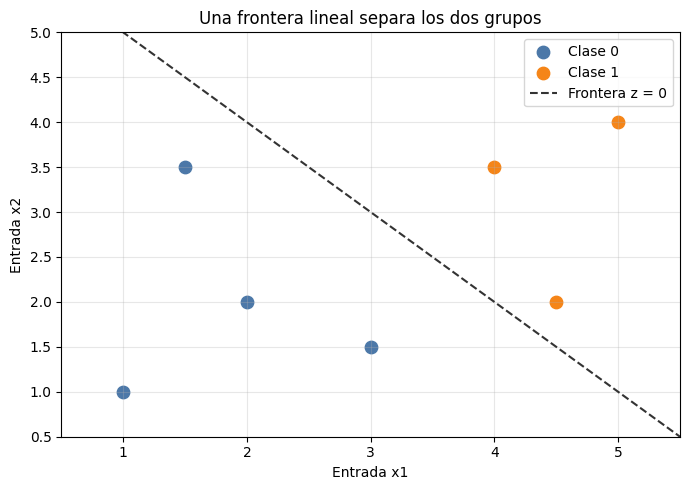

,x1,x2,clase_real,z,clase_predicha
0,1.0,1.0,0,-4.0,0
1,1.5,3.5,0,-1.0,0
2,2.0,2.0,0,-2.0,0
3,3.0,1.5,0,-1.5,0
4,4.0,3.5,1,1.5,1
5,4.5,2.0,1,0.5,1
6,5.0,4.0,1,3.0,1


In [8]:
puntos_lineales = pd.DataFrame(
    {
        "x1": [1.0, 1.5, 2.0, 3.0, 4.0, 4.5, 5.0],
        "x2": [1.0, 3.5, 2.0, 1.5, 3.5, 2.0, 4.0],
        "clase_real": [0, 0, 0, 0, 1, 1, 1],
    }
)

pesos_frontera = np.array([1.0, 1.0])
bias_frontera = -6.0

entradas_lineales = puntos_lineales[["x1", "x2"]].to_numpy()
puntos_lineales["z"] = np.dot(entradas_lineales, pesos_frontera) + bias_frontera
puntos_lineales["clase_predicha"] = (sigmoide(puntos_lineales["z"]) >= 0.5).astype(int)

x_recta = np.linspace(0.5, 5.5, 100)
y_recta = 6 - x_recta

fig, ax = plt.subplots(figsize=(7, 5))

for clase, color, etiqueta in [
    (0, "#4C78A8", "Clase 0"),
    (1, "#F58518", "Clase 1"),
]:
    grupo = puntos_lineales[puntos_lineales["clase_real"] == clase]
    ax.scatter(grupo["x1"], grupo["x2"], s=80, color=color, label=etiqueta)

ax.plot(x_recta, y_recta, color="#333333", linestyle="--", label="Frontera z = 0")
ax.set_title("Una frontera lineal separa los dos grupos")
ax.set_xlabel("Entrada x1")
ax.set_ylabel("Entrada x2")
ax.set_xlim(0.5, 5.5)
ax.set_ylim(0.5, 5.0)
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

puntos_lineales.assign(z=puntos_lineales["z"].round(2))


La recta discontinua corresponde a $x_1+x_2-6=0$. Los puntos con $z<0$ quedan de un lado y los puntos con $z>0$, del otro. Con estos parámetros, las siete clases predichas coinciden con las etiquetas del pequeño ejemplo.

Esto no constituye un resultado de evaluación ni demuestra que la neurona haya aprendido: elegimos los puntos y los parámetros para mostrar una separación lineal clara.


## 6. Lo que una sola neurona no puede separar

Consideremos ahora cuatro puntos dispuestos en un patrón cruzado. Los puntos de una misma clase ocupan esquinas opuestas.

Este patrón suele conocerse como **XOR**. No necesitamos estudiar su operación lógica: nos interesa observar su geometría y preguntarnos si una única recta puede dejar a una clase de un lado y a la otra del lado opuesto.


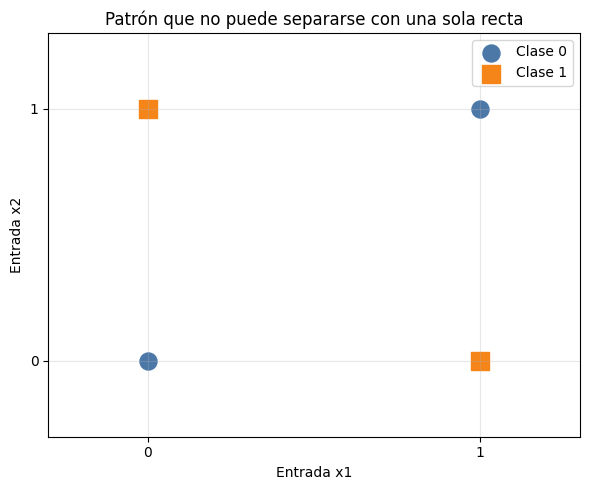

In [9]:
puntos_xor = pd.DataFrame(
    {
        "x1": [0, 0, 1, 1],
        "x2": [0, 1, 0, 1],
        "clase": [0, 1, 1, 0],
    }
)

fig, ax = plt.subplots(figsize=(6, 5))

for clase, color, marcador, etiqueta in [
    (0, "#4C78A8", "o", "Clase 0"),
    (1, "#F58518", "s", "Clase 1"),
]:
    grupo = puntos_xor[puntos_xor["clase"] == clase]
    ax.scatter(
        grupo["x1"],
        grupo["x2"],
        s=150,
        color=color,
        marker=marcador,
        label=etiqueta,
    )

ax.set_title("Patrón que no puede separarse con una sola recta")
ax.set_xlabel("Entrada x1")
ax.set_ylabel("Entrada x2")
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xlim(-0.3, 1.3)
ax.set_ylim(-0.3, 1.3)
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


No existe una única recta que deje ambos círculos de un lado y ambos cuadrados del otro. Como la frontera de decisión de una neurona de este tipo es lineal, ningún conjunto de pesos y bias puede clasificar correctamente los cuatro puntos al mismo tiempo.

Esta limitación explica por qué una neurona aislada no alcanza para representar relaciones más complejas. En el próximo capítulo veremos cómo conectar varias neuronas y organizarlas en capas, sin adelantar aquí esa construcción.


## 7. Una modificación para explorar

En la sección de la frontera lineal, cambiá `bias_frontera = -6.0` por `-5.0` y volvé a ejecutar la celda. La nueva frontera será $x_1+x_2-5=0$ y se desplazará en el plano.

Después podés restaurar el bias y cambiar `pesos_frontera` por `np.array([1.5, 1.0])`. En ese caso, la entrada $x_1$ tendrá mayor influencia y la inclinación de la frontera cambiará.

La exploración no busca encontrar la mejor combinación, sino relacionar cada parámetro con un cambio visible en la decisión de la neurona.


## Cierre

En este cuaderno implementamos el cálculo completo de una neurona artificial: recibimos entradas, multiplicamos cada una por su peso, sumamos los productos, incorporamos el bias y aplicamos una función sigmoide.

También distinguimos predicción de entrenamiento. Todos los parámetros utilizados fueron elegidos manualmente; todavía no construimos un mecanismo que aprenda a partir de ejemplos. Finalmente, vimos que una sola neurona puede representar una frontera lineal, pero no puede separar un patrón como XOR.

El próximo paso será conectar varias neuronas y estudiar cómo se organizan en capas para formar una red.


## Para pensar

1. Si una entrada tiene peso cero, ¿qué influencia tendrá sobre el resultado de la neurona?
2. ¿En qué se diferencia cambiar un peso de cambiar el bias?
3. ¿Por qué obtener salidas con parámetros elegidos manualmente no equivale a entrenar un modelo?
